In [2]:
import pandas as pd

df = pd.read_csv("covid_misinfo.csv")
print(df.shape)
df.head()

(5952, 34)


,s_no,Reported_On,Additional_Reporting,Retrieve_from_1,Retrieve_from_2,Retrieve_from_3,Twitter_Reference,Direct_Post_1,Direct_Post_2,Direct_Post_3,...,Motive_Description,Source,Source_Description,Distrib_Channel,Misinfo_Type,Key_Words,Summary,Coder,Notes,Region
0,1.0,https://www.buzzfeednews.com/article/ryanhates...,NaN,https://www.buzzfeednews.com/article/ryanhates...,NaN,NaN,0.0,NaN,NaN,NaN,...,Efforts to spread false claims on the origins ...,Individual actor,General public,Youtube,Conspiracy,"Coronavirus, India, bat soup",Hindi language Youtube account suggesting COVI...,Jan,NaN,NaN
1,2.0,https://twitter.com/Rangoli_A/status/122779241...,NaN,NaN,NaN,NaN,1.0,https://twitter.com/Rangoli_A/status/122779241...,NaN,NaN,...,"Twitter user stoking fear among other users, s...",Individual actor,General public,Twitter,False reporting,"Coronavirus, China, shooting","Tweet with video showing ""people getting shot ...",Jan,NaN,NaN
2,3.0,https://twitter.com/Woppa1Woppa/status/1220068...,NaN,NaN,NaN,NaN,1.0,https://twitter.com/Woppa1Woppa/status/1220068...,NaN,NaN,...,Twitter user discrediting Chinese-American pop...,Individual actor,General public,Twitter,False reporting,"Coronavirus, Chinese food, bat soup","Video of an individual eating a delicacy, and ...",Jan,NaN,NaN
3,4.0,https://twitter.com/FreddiGoldstein/status/123...,NaN,NaN,NaN,NaN,1.0,https://twitter.com/FreddiGoldstein/status/123...,NaN,NaN,...,Chain message spread to stoke fear among Ameri...,Individual actor,General public,"Media, SMS",False reporting,"Coronavirus, NYPD, containment zone",Tweet with a screenshot of chain message sugge...,Jan,NaN,NaN
4,5.0,https://www.boomlive.in/health/hoax-alert-vira...,NaN,https://www.boomlive.in/health/hoax-alert-vira...,NaN,NaN,0.0,NaN,NaN,NaN,...,Chain message spread to stoke fear among India...,Individual actor,General public,"Facebook, WhatsApp",False reporting,"Coronavirus, India, travel advisory",WhatsApp chain message circulating among India...,Jan,NaN,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5952 entries, 0 to 5951
Data columns (total 34 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   s_no                     5636 non-null   float64
 1   Reported_On              5612 non-null   str    
 2   Additional_Reporting     288 non-null    str    
 3   Retrieve_from_1          2456 non-null   str    
 4   Retrieve_from_2          504 non-null    str    
 5   Retrieve_from_3          252 non-null    str    
 6   Twitter_Reference        5613 non-null   float64
 7   Direct_Post_1            1720 non-null   str    
 8   Direct_Post_2            699 non-null    str    
 9   Direct_Post_3            398 non-null    str    
 10  Direct_Post_4            266 non-null    str    
 11  Title                    5596 non-null   str    
 12  Publication_Date         5613 non-null   str    
 13  Entry_Date               5613 non-null   str    
 14  Primary_Country          5611 non-n

In [4]:
df.columns.tolist()

['s_no',
 'Reported_On',
 'Additional_Reporting',
 'Retrieve_from_1',
 'Retrieve_from_2',
 'Retrieve_from_3',
 'Twitter_Reference',
 'Direct_Post_1',
 'Direct_Post_2',
 'Direct_Post_3',
 'Direct_Post_4',
 'Title',
 'Publication_Date',
 'Entry_Date',
 'Primary_Country',
 'Secondary_Country',
 'Primary_Language',
 'Secondary_Language',
 'Main_Narrative',
 'Recoded_Main_Narrative',
 'Recoded_Narrative_Coder',
 'Narrative_Description',
 'ChainMsg_or_Email',
 'Motive',
 'Motive_Description',
 'Source',
 'Source_Description',
 'Distrib_Channel',
 'Misinfo_Type',
 'Key_Words',
 'Summary',
 'Coder',
 'Notes',
 'Region']

Important Columns

Primary_Country — where the misinfo came from


Primary_Language — what language it was in


Motive — why it was spread (things like political, financial, etc.)


Source — who/what originated it


Distrib_Channel — where it spread (social media, messaging apps...)


Misinfo_Type — the kind of falsehood (fabricated, misleading, etc.)


Main_Narrative — the theme of the claim (what the lie was about)


Publication_Date — when — good for a time-trend line chart

In [5]:
for col in ['Primary_Country', 'Motive', 'Source', 'Distrib_Channel', 'Misinfo_Type', 'Primary_Language']:
    print("=" * 40)
    print(col, "—", df[col].nunique(), "unique values")
    print(df[col].value_counts().head(10))
    print()

Primary_Country — 193 unique values
Primary_Country
China            449
United States    441
Turkey           300
Ambiguous        260
Spain            254
Germany          229
Brazil           210
India            205
Egypt            196
Italy            149
Name: count, dtype: int64

Motive — 14 unique values
Motive
Fear                                      1749
Politics                                  1023
Other                                      935
False Hope                                 570
Undermine target country institutions      458
Downplay Severity                          329
Help                                       222
Profit                                     195
Undermine target country                   122
Downplay severity                            3
Name: count, dtype: int64

Source — 31 unique values
Source
Individual actor            4079
Media                        680
Individual actors            395
Political actor              277
State sponsors  

"Fear" (1,749) and "Politics" (1,023) dominate. Most COVID misinformation wasn't about profit or fake cures, it was about fear and politics. Pair it with Misinfo_Type : what kind of lies, and why people spread them.

The one issue to fix: messy duplicate categories
same category shows up multiple times with different capitalization or wording:

Motive: Downplay Severity (329) vs Downplay severity (3)
Source: Individual actor (4079) vs Individual actors (395) vs Individual Actors (7) — all the same thing!
Misinfo_Type: False reporting (4123) vs False Reporting (3) vs false reporting (3)
Distrib_Channel: Social media vs Social Media, WhatsApp vs Whatsapp

In [6]:
# Standardize capitalization and strip spaces for the key columns
for col in ['Motive', 'Source', 'Misinfo_Type', 'Distrib_Channel', 'Primary_Country', 'Primary_Language']:
    df[col] = df[col].str.strip().str.title()

# Quick re-check on the cleaner columns
for col in ['Motive', 'Misinfo_Type']:
    print("=" * 40)
    print(col)
    print(df[col].value_counts().head(10))
    print()

Motive
Motive
Fear                                     1749
Politics                                 1023
Other                                     937
False Hope                                572
Undermine Target Country Institutions     459
Downplay Severity                         332
Help                                      222
Profit                                    195
Undermine Target Country                  123
Name: count, dtype: int64

Misinfo_Type
Misinfo_Type
False Reporting                 4129
Conspiracy                       966
Fake Remedy                      502
Conspiracy, False Reporting        5
Fake Remedy, False Reporting       3
False Reporting, Fake Remedy       1
False Reporting, Conspiracy        1
Conspiracy, Fake Remedy            1
Fake Remedy, Conspiracy            1
Name: count, dtype: int64



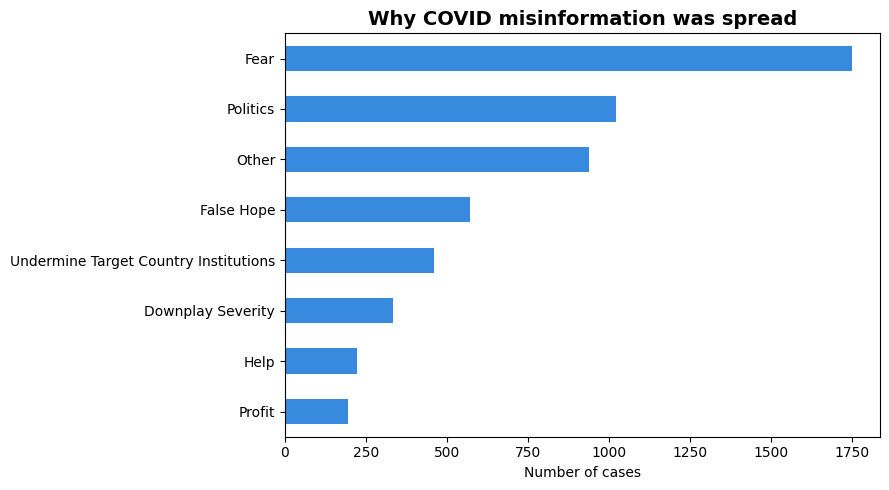

In [9]:
import matplotlib.pyplot as plt

# Summary
motive_summary = df['Motive'].value_counts().head(8)

# Save for DataWrapper
motive_summary.to_csv("chart_motive.csv", header=["count"])

# Plot in notebook
plt.figure(figsize=(9, 5))
motive_summary.sort_values().plot(kind='barh', color='#378add')
plt.title('Why COVID misinformation was spread', fontsize=14, fontweight='bold')
plt.xlabel('Number of cases')
plt.ylabel('')
plt.tight_layout()
plt.show()

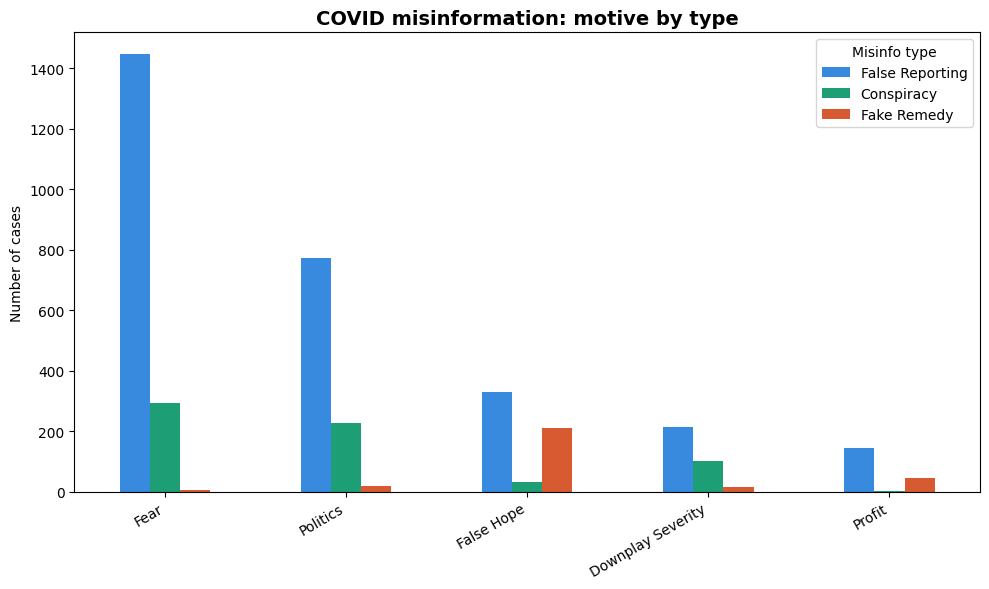

In [ ]:
main_types = ['False Reporting', 'Conspiracy', 'Fake Remedy']
top_motives = ['Fear', 'Politics', 'False Hope', 'Downplay Severity', 'Profit']

mask = df['Motive'].isin(top_motives) & df['Misinfo_Type'].isin(main_types)
crosstab = pd.crosstab(df[mask]['Motive'], df[mask]['Misinfo_Type'])

crosstab = crosstab.loc[top_motives, main_types]

# Save for DataWrapper
crosstab.to_csv("chart_motive_by_type.csv")

# Plot in notebook
crosstab.plot(kind='bar', figsize=(10, 6),
              color=['#378add', '#1d9e75', '#d85a30'])
plt.title('COVID misinformation: motive by type', fontsize=14, fontweight='bold')
plt.xlabel('')
plt.ylabel('Number of cases')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Misinfo type')
plt.tight_layout()
plt.show()

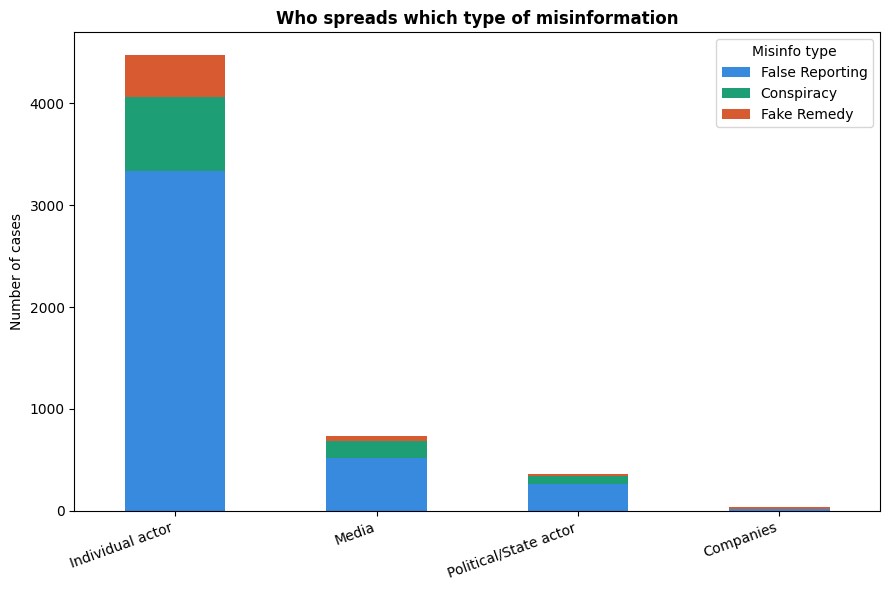

In [11]:
# Clean & group Source into a few clear buckets
def group_source(s):
    s = str(s).lower()
    if 'political' in s or 'state' in s: return 'Political/State actor'
    if 'media' in s: return 'Media'
    if 'compan' in s: return 'Companies'
    if 'individual' in s: return 'Individual actor'
    return 'Other'

df['Source_grouped'] = df['Source'].apply(group_source)

main_types = ['False Reporting', 'Conspiracy', 'Fake Remedy']
src_order = ['Individual actor', 'Media', 'Political/State actor', 'Companies']

mask = df['Source_grouped'].isin(src_order) & df['Misinfo_Type'].isin(main_types)
source_type = pd.crosstab(df[mask]['Source_grouped'], df[mask]['Misinfo_Type']).loc[src_order, main_types]
source_type.to_csv("chart_source_type.csv")

source_type.plot(kind='bar', stacked=True, figsize=(9,6),
                 color=['#378add', '#1d9e75', '#d85a30'])
plt.title('Who spreads which type of misinformation', fontweight='bold')
plt.ylabel('Number of cases'); plt.xlabel('')
plt.xticks(rotation=20, ha='right'); plt.legend(title='Misinfo type')
plt.tight_layout(); plt.show()

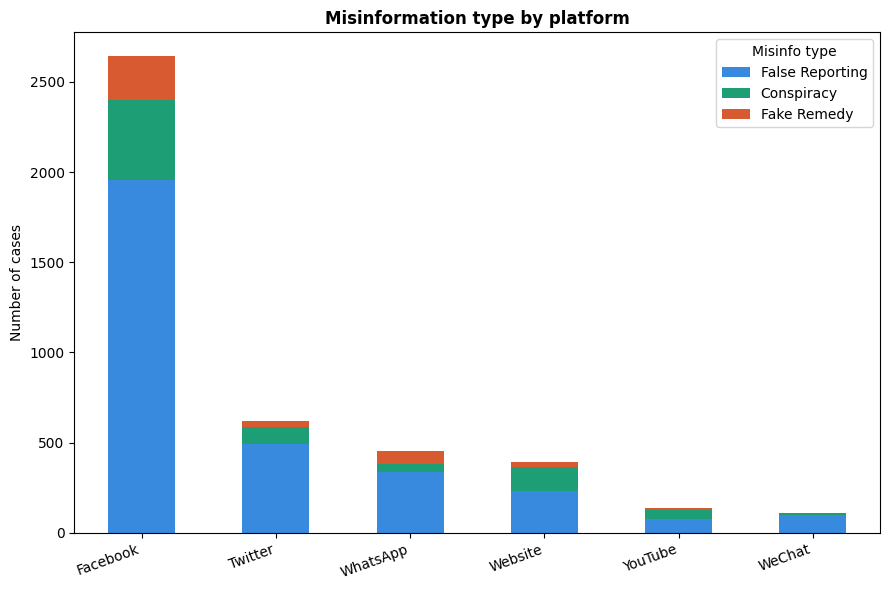

: 

In [ ]:
# Clean & group the messy channel column into major platforms
def group_platform(s):
    s = str(s).lower()
    if 'facebook' in s: return 'Facebook'
    if 'whatsapp' in s: return 'WhatsApp'
    if 'twitter' in s: return 'Twitter'
    if 'youtube' in s: return 'YouTube'
    if 'wechat' in s: return 'WeChat'
    if 'instagram' in s: return 'Instagram'
    if 'website' in s or 'web' in s: return 'Website'
    return 'Other'

df['Platform'] = df['Distrib_Channel'].apply(group_platform)

plat_order = ['Facebook', 'Twitter', 'WhatsApp', 'Website', 'YouTube', 'WeChat']
mask = df['Platform'].isin(plat_order) & df['Misinfo_Type'].isin(main_types)
plat_type = pd.crosstab(df[mask]['Platform'], df[mask]['Misinfo_Type']).loc[plat_order, main_types]
plat_type.to_csv("chart_platform_type.csv")

plat_type.plot(kind='bar', stacked=True, figsize=(9,6),
               color=['#378add', '#1d9e75', '#d85a30'])
plt.title('Misinformation type by platform', fontweight='bold')
plt.ylabel('Number of cases'); plt.xlabel('')
plt.xticks(rotation=20, ha='right'); plt.legend(title='Misinfo type')
plt.tight_layout(); plt.show()